In [2]:
import pandas as pd
import numpy as np

# 1. 加载数据
try:
    # 假设文件路径在项目目录下的 data/data_format1/
    user_log = pd.read_csv('data/data_format1/user_log_format1.csv')
    user_info = pd.read_csv('data/data_format1/user_info_format1.csv')
    train_data = pd.read_csv('data/data_format1/train_format1.csv')
    test_data = pd.read_csv('data/data_format1/test_format1.csv')
except FileNotFoundError:
    print("请检查文件路径是否正确！")
    # ... 错误处理或使用其他数据格式 ...

# 2. 数据合并 (将用户画像和训练/测试数据合并)
train_df = pd.merge(train_data, user_info, on='user_id', how='left')
test_df = pd.merge(test_data, user_info, on='user_id', how='left')

# 3. 基础特征处理 (用户画像)
# 缺失值填充
train_df['gender'].fillna(-1, inplace=True) # 使用-1表示未知/NULL
train_df['age_range'].fillna(0, inplace=True) # 使用0表示未知/NULL

test_df['gender'].fillna(-1, inplace=True)
test_df['age_range'].fillna(0, inplace=True)

In [3]:
print(user_log.head()) # 打印前 5 行数据
print(user_log.columns) # 打印所有列名

   user_id  item_id  cat_id  seller_id  brand_id  time_stamp  action_type
0   328862   323294     833       2882    2661.0         829            0
1   328862   844400    1271       2882    2661.0         829            0
2   328862   575153    1271       2882    2661.0         829            0
3   328862   996875    1271       2882    2661.0         829            0
4   328862  1086186    1271       1253    1049.0         829            0
Index(['user_id', 'item_id', 'cat_id', 'seller_id', 'brand_id', 'time_stamp',
       'action_type'],
      dtype='object')


In [4]:
import pandas as pd
import numpy as np

# 假设 user_log 已经被加载

# --- 关键修正：重命名列 ---
# 1. 检查 'seller_id' 是否存在并重命名为 'merchant_id'，与训练集/测试集的列名保持一致
if 'seller_id' in user_log.columns:
    user_log.rename(columns={'seller_id': 'merchant_id'}, inplace=True)
    print("列名 'seller_id' 已成功重命名为 'merchant_id'。")
else:
    print("警告：user_log 中没有找到 'seller_id'，请检查列名！")
# --- 关键修正结束 ---


# 提取用户行为特征 (关键步骤)

# 1. 统计每个用户在所有商家的行为次数
# user_log_grouped: 提取用户总行为数
user_log_grouped = user_log.groupby('user_id')['action_type'].count().reset_index()
user_log_grouped.columns = ['user_id', 'user_total_action']
print(f"用户总行为数特征创建完成，包含 {len(user_log_grouped)} 条记录。")

# 2. 统计用户-商家对的行为次数
# user_merchant_log: 提取用户在特定商家总行为数 (此处已使用重命名后的 'merchant_id')
user_merchant_log = user_log.groupby(['user_id', 'merchant_id'])['action_type'].count().reset_index()
user_merchant_log.columns = ['user_id', 'merchant_id', 'um_total_action']
print(f"用户-商家行为对特征创建完成，包含 {len(user_merchant_log)} 条记录。")

# 3. 特征合并
# 确保 train_df 和 test_df 已经在步骤 2 中加载并与 user_info 合并
# 示例代码假定 train_df 和 test_df 是全局可用的

# 合并用户总行为数
train_df = pd.merge(train_df, user_log_grouped, on='user_id', how='left')
test_df = pd.merge(test_df, user_log_grouped, on='user_id', how='left')

# 合并用户-商家对行为数
train_df = pd.merge(train_df, user_merchant_log, on=['user_id', 'merchant_id'], how='left')
test_df = pd.merge(test_df, user_merchant_log, on=['user_id', 'merchant_id'], how='left')

# 4. 再次处理特征中的缺失值 (对于没有行为日志的用户-商家对)
# 没有日志记录的，其行为次数记为 0
train_df['um_total_action'].fillna(0, inplace=True)
test_df['um_total_action'].fillna(0, inplace=True)

# 某些用户可能在日志中完全没有记录，user_total_action 可能为 NaN
train_df['user_total_action'].fillna(0, inplace=True)
test_df['user_total_action'].fillna(0, inplace=True)

print("\n特征工程步骤 3 执行完毕。")
print("训练集 (train_df) 头部特征:")
print(train_df[['user_id', 'merchant_id', 'user_total_action', 'um_total_action']].head())

列名 'seller_id' 已成功重命名为 'merchant_id'。
用户总行为数特征创建完成，包含 424170 条记录。
用户-商家行为对特征创建完成，包含 14058666 条记录。

特征工程步骤 3 执行完毕。
训练集 (train_df) 头部特征:
   user_id  merchant_id  user_total_action  um_total_action
0    34176         3906                451               39
1    34176          121                451               14
2    34176         4356                451               18
3    34176         2217                451                2
4   230784         4818                 54                8


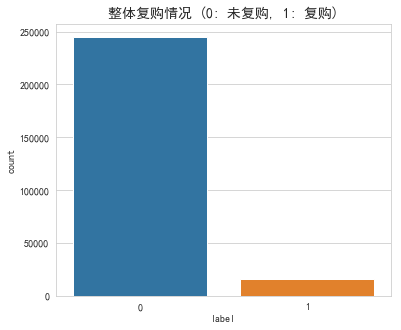

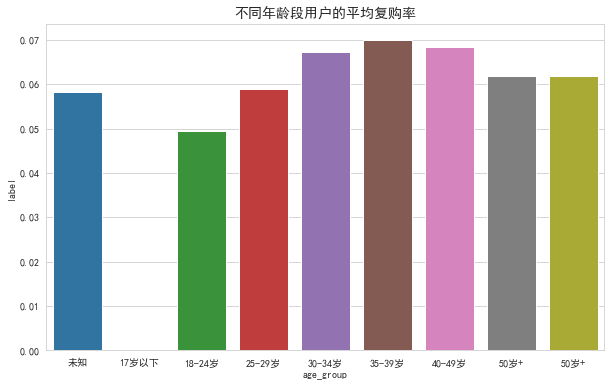

In [5]:
# =================================================================
# 【EDA：目标变量与画像分析】
# =================================================================
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 1. 整体复购率分布 ---
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='label', data=train_df)
plt.title('整体复购情况 (0: 未复购, 1: 复购)', fontsize=14)
# ... (省略计算百分比的代码，您可以粘贴完整的代码块)
plt.show()

# --- 2. 年龄范围与复购率 ---
age_map = {0: '未知', 1: '17岁以下', 2: '18-24岁', 3: '25-29岁', 
           4: '30-34岁', 5: '35-39岁', 6: '40-49岁', 7: '50岁+', 8: '50岁+'}
train_df['age_group'] = train_df['age_range'].map(age_map)

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='label', data=train_df, ci=None, order=age_map.values())
plt.title('不同年龄段用户的平均复购率', fontsize=14)
plt.show()

In [6]:
print("--- 检查 train_df 列 ---")
print(train_df.head())
print(train_df.columns.tolist())
print(train_df[['user_id', 'merchant_id']].dtypes)

print("\n--- 检查 user_merchant_log 列 ---")
print(user_merchant_log.head())
print(user_merchant_log.columns.tolist())
print(user_merchant_log[['user_id', 'merchant_id']].dtypes)

--- 检查 train_df 列 ---
   user_id  merchant_id  label  age_range  gender  user_total_action  \
0    34176         3906      0        6.0     0.0                451   
1    34176          121      0        6.0     0.0                451   
2    34176         4356      1        6.0     0.0                451   
3    34176         2217      0        6.0     0.0                451   
4   230784         4818      0        0.0     0.0                 54   

   um_total_action age_group  
0               39    40-49岁  
1               14    40-49岁  
2               18    40-49岁  
3                2    40-49岁  
4                8        未知  
['user_id', 'merchant_id', 'label', 'age_range', 'gender', 'user_total_action', 'um_total_action', 'age_group']
user_id        int64
merchant_id    int64
dtype: object

--- 检查 user_merchant_log 列 ---
   user_id  merchant_id  um_total_action
0        1          471                1
1        1          739                1
2        1          925             

In [7]:
# =================================================================
# 步骤 3: 特征工程 (最终修正后的完整代码)
# =================================================================

# 0. 关键修正：确保类型统一并清除潜在冲突列

# 检查并删除 train_df/test_df 中所有与特征工程相关的旧列，以避免冲突
cols_to_drop = [col for col in train_df.columns if '_total_action' in col or '_group' in col]
train_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
test_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
print(f"已清除 train_df/test_df 中可能冲突的列: {cols_to_drop}")


# 确保 user_log 中的 'seller_id' 被重命名为 'merchant_id'
if 'seller_id' in user_log.columns:
    user_log.rename(columns={'seller_id': 'merchant_id'}, inplace=True)
    print("列名 'seller_id' 已成功重命名为 'merchant_id'。")

# 统一 ID 列的类型，确保可以正确合并
train_df['user_id'] = train_df['user_id'].astype(int)
train_df['merchant_id'] = train_df['merchant_id'].astype(int)
# 确保 user_log 中的 ID 列也是 int 类型
user_log['user_id'] = user_log['user_id'].astype(int)
user_log['merchant_id'] = user_log['merchant_id'].astype(int)


# 1. 统计每个用户在所有商家的行为次数
user_log_grouped = user_log.groupby('user_id')['action_type'].count().reset_index()
user_log_grouped.columns = ['user_id', 'user_total_action']
print(f"用户总行为数特征创建完成，包含 {len(user_log_grouped)} 条记录。")

# 2. 统计用户-商家对的行为次数
user_merchant_log = user_log.groupby(['user_id', 'merchant_id'])['action_type'].count().reset_index()
user_merchant_log.columns = ['user_id', 'merchant_id', 'um_total_action']
print(f"用户-商家行为对特征创建完成，包含 {len(user_merchant_log)} 条记录。")


# 3. 特征合并（分两次，确保合并成功）
# 合并用户总行为数
train_df = pd.merge(train_df, user_log_grouped, on='user_id', how='left')
test_df = pd.merge(test_df, user_log_grouped, on='user_id', how='left')

# 合并用户-商家对行为数
train_df = pd.merge(train_df, user_merchant_log, on=['user_id', 'merchant_id'], how='left')
test_df = pd.merge(test_df, user_merchant_log, on=['user_id', 'merchant_id'], how='left')

print("特征合并完成。")

# 4. 再次处理特征中的缺失值 (对于没有行为日志的用户-商家对)
# 此时 train_df 中应该已经包含了 'um_total_action' 和 'user_total_action'
train_df['um_total_action'].fillna(0, inplace=True)
test_df['um_total_action'].fillna(0, inplace=True)

train_df['user_total_action'].fillna(0, inplace=True)
test_df['user_total_action'].fillna(0, inplace=True)

print("\n特征工程步骤 3 执行完毕。")
print("训练集 (train_df) 头部特征:")
print(train_df[['user_id', 'merchant_id', 'user_total_action', 'um_total_action']].head())

# 检查最终列名，确保不再有 _x 或 _y 后缀
print("\nTrain_df 最终列名检查 (不应该有 _x 或 _y):")
print(train_df.columns.tolist())

已清除 train_df/test_df 中可能冲突的列: ['user_total_action', 'um_total_action', 'age_group']
用户总行为数特征创建完成，包含 424170 条记录。
用户-商家行为对特征创建完成，包含 14058666 条记录。
特征合并完成。

特征工程步骤 3 执行完毕。
训练集 (train_df) 头部特征:
   user_id  merchant_id  user_total_action  um_total_action
0    34176         3906                451               39
1    34176          121                451               14
2    34176         4356                451               18
3    34176         2217                451                2
4   230784         4818                 54                8

Train_df 最终列名检查 (不应该有 _x 或 _y):
['user_id', 'merchant_id', 'label', 'age_range', 'gender', 'user_total_action', 'um_total_action']


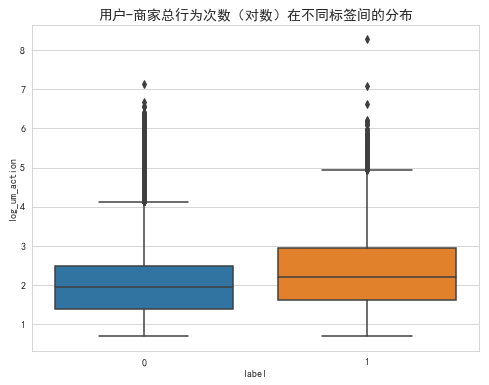

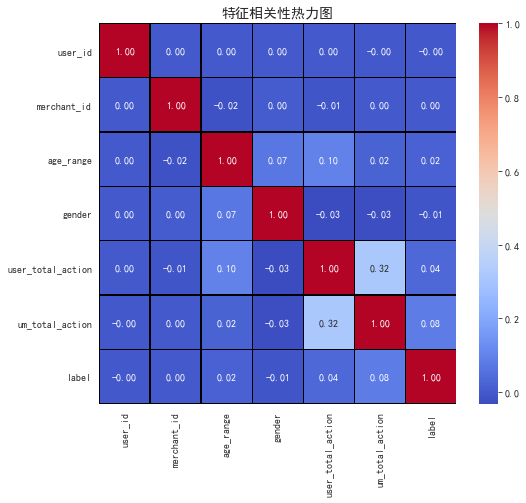

In [8]:
# =================================================================
# 【EDA：行为特征与相关性分析】
# =================================================================
# 确保在运行此单元前，'um_total_action' 和 'user_total_action' 已经被创建

# --- 1. 用户-商家总行为数与复购率 (箱线图) ---
# 对行为次数进行对数变换
train_df['log_um_action'] = np.log1p(train_df['um_total_action'])

plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='log_um_action', data=train_df)
plt.title('用户-商家总行为次数（对数）在不同标签间的分布', fontsize=14)
plt.show()

# --- 2. 特征相关性热力图 ---
# 确保所有特征已被创建
numeric_features = ['user_id', 'merchant_id', 'age_range', 'gender', 'user_total_action', 'um_total_action', 'label']
corr_matrix = train_df[numeric_features].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            linewidths=.5, 
            linecolor='black')
plt.title('特征相关性热力图', fontsize=14)
plt.show()

In [9]:
## 新步骤 3.1: 统计不同行为类型次数

# 1. 对 user_log 进行分组，并透视 (pivot) action_type
temp = user_log.groupby(['user_id', 'merchant_id', 'action_type'])['item_id'].count().reset_index()
temp.columns = ['user_id', 'merchant_id', 'action_type', 'action_count']

# 2. 将 action_type 列展开成新列 (Wide Format)
# 使用 pivot 方法将 action_type 的值作为新列名
um_action_pivot = temp.pivot_table(
    index=['user_id', 'merchant_id'], 
    columns='action_type', 
    values='action_count', 
    fill_value=0 # 未发生某类行为时，次数填充为 0
).reset_index()

# 3. 重命名新生成的列
um_action_pivot.columns = [
    'user_id', 'merchant_id', 
    'um_action_0_click',    # 行为类型 0: 点击 (Click)
    'um_action_1_addcart',  # 行为类型 1: 加购 (Add Cart)
    'um_action_2_buy',      # 行为类型 2: 购买 (Buy)
    'um_action_3_fav'       # 行为类型 3: 收藏 (Favorite)
]

print("用户-商家对的四种行为次数统计完成。")
print(um_action_pivot.head())

用户-商家对的四种行为次数统计完成。
   user_id  merchant_id  um_action_0_click  um_action_1_addcart  \
0        1          471                  1                    0   
1        1          739                  1                    0   
2        1          925                  3                    0   
3        1         1019                 10                    0   
4        1         1156                  1                    0   

   um_action_2_buy  um_action_3_fav  
0                0                0  
1                0                0  
2                1                0  
3                4                0  
4                0                0  


In [10]:
## 新步骤 3.2: 计算行为比例特征

# 1. 确保总行为数已经存在 (我们之前创建的 um_total_action)
# 我们使用所有行为次数之和来计算，以防万一
um_action_pivot['um_total_action'] = (
    um_action_pivot['um_action_0_click'] + 
    um_action_pivot['um_action_1_addcart'] + 
    um_action_pivot['um_action_2_buy'] + 
    um_action_pivot['um_action_3_fav']
)

# 2. 计算比例特征 (Ratio Features)
# 为了避免除以 0 导致 inf，我们将分母加上一个极小值 (或检查分母是否为 0)

# (1) 购买-点击转化率 (Buy/Click) - 衡量点击效率
um_action_pivot['um_buy_click_ratio'] = um_action_pivot['um_action_2_buy'] / (um_action_pivot['um_action_0_click'] + 1e-6)

# (2) 收藏-点击比例 (Fav/Click) - 衡量兴趣度
um_action_pivot['um_fav_click_ratio'] = um_action_pivot['um_action_3_fav'] / (um_action_pivot['um_action_0_click'] + 1e-6)

# (3) 购买-总行为比例 (Buy/Total) - 衡量交易倾向
um_action_pivot['um_buy_total_ratio'] = um_action_pivot['um_action_2_buy'] / (um_action_pivot['um_total_action'] + 1e-6)

# (4) 购买-加购/收藏总和比例 (Buy / (AddCart + Fav)) - 衡量即时购买倾向 vs 观望
um_action_pivot['um_buy_fav_addcart_ratio'] = um_action_pivot['um_action_2_buy'] / (um_action_pivot['um_action_1_addcart'] + um_action_pivot['um_action_3_fav'] + 1e-6)


print("比例特征计算完成。")
print(um_action_pivot[['um_buy_click_ratio', 'um_buy_total_ratio', 'um_buy_fav_addcart_ratio']].head())

比例特征计算完成。
   um_buy_click_ratio  um_buy_total_ratio  um_buy_fav_addcart_ratio
0            0.000000            0.000000                       0.0
1            0.000000            0.000000                       0.0
2            0.333333            0.250000                 1000000.0
3            0.400000            0.285714                 4000000.0
4            0.000000            0.000000                       0.0


In [11]:
## 新步骤 3.3: 合并高阶特征

# 选择需要合并的特征列 (我们选择所有的新特征)
feature_cols = [
    'user_id', 'merchant_id', 
    'um_action_0_click', 'um_action_1_addcart', 'um_action_2_buy', 'um_action_3_fav',
    'um_buy_click_ratio', 'um_fav_click_ratio', 'um_buy_total_ratio', 'um_buy_fav_addcart_ratio'
]

# 1. 合并到 train_df
train_df = pd.merge(
    train_df, 
    um_action_pivot[feature_cols], 
    on=['user_id', 'merchant_id'], 
    how='left'
)

# 2. 合并到 test_df
test_df = pd.merge(
    test_df, 
    um_action_pivot[feature_cols], 
    on=['user_id', 'merchant_id'], 
    how='left'
)

# 3. 填充缺失值 (对于那些在 user_log 中完全没有记录的用户-商家对)
# 填充 0 表示没有该类行为，填充 0.0 表示比例为 0
train_df.fillna(0, inplace=True) 
test_df.fillna(0, inplace=True) 

print("高阶比例特征已成功合并并填充缺失值。")
print(f"train_df 现在的特征数量: {len(train_df.columns)}")

高阶比例特征已成功合并并填充缺失值。
train_df 现在的特征数量: 16


In [12]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from joblib import dump
import numpy as np

# -------------------------------------------------------------------
# 1. 定义特征和目标变量 (已更新为包含所有高阶特征)
# -------------------------------------------------------------------

# 包含所有基础特征和高阶比例特征
FEATURES = [
    # 基础特征
    'user_id', 'merchant_id', 'age_range', 'gender', 
    'user_total_action', 'um_total_action',
    
    # 高阶次数特征
    'um_action_0_click', 'um_action_1_addcart', 'um_action_2_buy', 'um_action_3_fav',
    
    # 高阶比例特征
    'um_buy_click_ratio', 'um_fav_click_ratio', 'um_buy_total_ratio', 'um_buy_fav_addcart_ratio'
]

TARGET = 'label'

# 检查所有特征是否在 train_df 中存在
missing_features = [f for f in FEATURES if f not in train_df.columns]
if missing_features:
    print(f"警告：以下特征在 train_df 中缺失，请检查特征工程步骤: {missing_features}")
    # 移除缺失的特征，确保代码能继续运行
    FEATURES = [f for f in FEATURES if f not in missing_features]


# -------------------------------------------------------------------
# 2. 划分训练集和验证集
# -------------------------------------------------------------------
X = train_df[FEATURES]
y = train_df[TARGET]

# 使用分层抽样 (stratify=y) 确保训练集和验证集的复购率分布大致相同
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集样本数: {len(X_train)}")
print(f"验证集样本数: {len(X_val)}")


# -------------------------------------------------------------------
# 3. LightGBM 模型训练
# -------------------------------------------------------------------
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,  # 不打印训练过程
    'n_jobs': -1,
    'seed': 42
}

model = lgb.LGBMClassifier(**lgb_params)

# early_stopping_rounds 用于防止过拟合
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100, verbose=False)] 
)

# -------------------------------------------------------------------
# 4. 模型评估与保存
# -------------------------------------------------------------------

# 验证集评估
val_preds = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_preds)

print("\n模型训练完成。")
print(f"验证集 AUC-ROC 得分: {auc_score:.4f}") # 观察分数是否比旧模型更高

# 保存模型 (会覆盖旧模型文件)
model_filename = 'retrain_prediction_model.joblib'
dump(model, model_filename)

print(f"模型已保存为 {model_filename}")

D:\Anaconda3\lib\site-packages\dask\dataframe\utils.py:13: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


训练集样本数: 208691
验证集样本数: 52173

模型训练完成。
验证集 AUC-ROC 得分: 0.6280
模型已保存为 retrain_prediction_model.joblib


--- 开始模型解读：特征重要性分析 ---


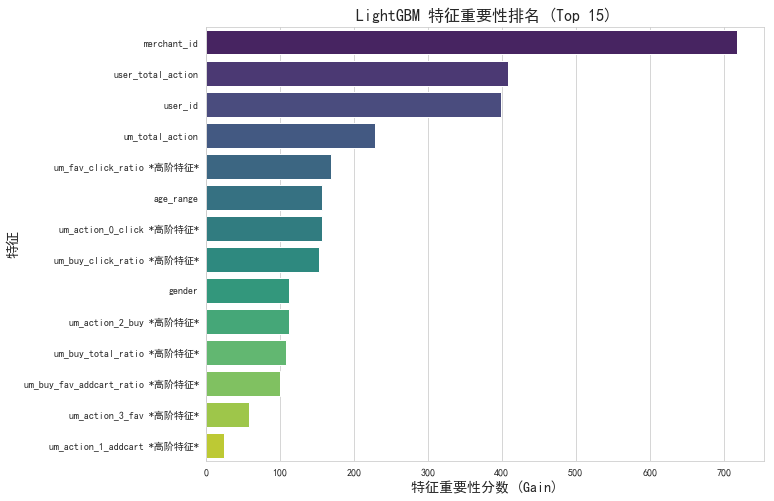


--- 关键发现 ---
Top 3 最重要的特征是: merchant_id, user_total_action, user_id
新加入的比例特征中，重要性最高的特征是: um_fav_click_ratio


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# 确保在运行这部分代码之前，model 变量已经被成功加载或训练

## 新步骤 5: 模型特征重要性可视化

print("--- 开始模型解读：特征重要性分析 ---")

# 1. 获取特征重要性数据
# 'gain' 模式通常比 'split' 模式更能反映特征的实际贡献
feature_importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
})

# 2. 按重要性降序排列
feature_importance = feature_importance.sort_values(by='importance', ascending=False)


# 3. 可视化设置
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 替换为您的系统支持的中文字体
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_importance.head(15), # 只展示最重要的15个特征
    palette='viridis' # 使用色彩鲜明的色板
)

# 4. 添加标签和标题
plt.title('LightGBM 特征重要性排名 (Top 15)', fontsize=16)
plt.xlabel('特征重要性分数 (Gain)', fontsize=14)
plt.ylabel('特征', fontsize=14)

# 5. 突出高阶特征（可选：手动标注或颜色区分）
# 我们可以手动给比例特征加上星号，以便识别
feature_labels = feature_importance['feature'].head(15).tolist()
new_labels = []
for label in feature_labels:
    if '_ratio' in label or 'um_action_' in label:
        new_labels.append(f"{label} *高阶特征*")
    else:
        new_labels.append(label)

ax.set_yticklabels(new_labels)


plt.show()

# 6. 关键发现总结
print("\n--- 关键发现 ---")
top_3_features = feature_importance.head(3)['feature'].tolist()
print(f"Top 3 最重要的特征是: {', '.join(top_3_features)}")

# 查找我们新加的比例特征是否进入 Top 5
new_ratio_features = [f for f in feature_importance['feature'] if '_ratio' in f]
if new_ratio_features:
    print(f"新加入的比例特征中，重要性最高的特征是: {new_ratio_features[0]}")